In [11]:
import pandas as pd
import numpy as np
import os
import random

# seed para reprodutibilidade
np.random.seed(42)
random.seed(42)

# --- configuracoes de saida ---
output_dir = r"c:\Users\john.araujo\OneDrive - unb.br\PC SIA\arquivos_projeto_pratico\PROJETO_DISSERTACAO_ENRIQUECIMENTO\FASE_1_INTELIGENCIA_REAL\2_dados_saida"
os.makedirs(output_dir, exist_ok=True)



In [12]:
# --- definicao dos 10 alvos e seus perfis ---
alvos = {
    "owasp-juice-shop.local": {"perfil": "Importante", "base_paths": ["/api/", "/rest/", "/assets/", "/ftp/", "/#/", "/socket.io/"]},
    "dvwa.local": {"perfil": "Negligenciado", "base_paths": ["/vulnerabilities/sqli/", "/vulnerabilities/xss_r/", "/vulnerabilities/exec/", "/vulnerabilities/upload/", "/config/"]},
    "webgoat.local": {"perfil": "Importante", "base_paths": ["/WebGoat/SqlInjection/", "/WebGoat/xxe/", "/WebGoat/jwt/", "/WebGoat/deserialization/", "/WebGoat/static/"]},
    "bwapp.local": {"perfil": "Negligenciado", "base_paths": ["/sqli_1.php", "/xss_get.php", "/commandi.php", "/directory_traversal_1.php", "/images/", "/admin/"]},
    "mutillidae.local": {"perfil": "Aleatório", "base_paths": ["/index.php?page=", "/javascript/", "/webservices/", "/classes/", "/passwords/"]},
    "gruyere.local": {"perfil": "Aleatório", "base_paths": ["/12345/newsnippet.gtl", "/12345/saveprofile", "/12345/upload", "/static/"]},
    "xvwa.local": {"perfil": "Negligenciado", "base_paths": ["/vulnerabilities/ssrf/", "/vulnerabilities/ssti/", "/vulnerabilities/redirect/", "/components/"]},
    "altoromutual.local": {"perfil": "Importante", "base_paths": ["/bank/login.aspx", "/search.aspx", "/bank/account.aspx", "/admin/", "/images/"]},
    "dvga.local": {"perfil": "Importante", "base_paths": ["/graphql", "/api/v1/", "/static/js/"]},
    "vulnerableapp.local": {"perfil": "Aleatório", "base_paths": ["/VulnerableApp/PathTraversal", "/VulnerableApp/SQLInjection", "/VulnerableApp/SSRF", "/static/css/"]}
}

# --- pool de vulnerabilidades reais ---
pool_vulnerabilidades = [
    # alta criticidade
    {"nome": "SQL Injection", "cve": "CVE-2015-5374", "cvss": 9.8, "severity": "CRITICAL", "epss_range": (0.5, 0.9)},
    {"nome": "OS Command Injection", "cve": "CVE-2019-16662", "cvss": 9.8, "severity": "CRITICAL", "epss_range": (0.6, 0.95)},
    {"nome": "Server Side Template Injection", "cve": "CVE-2022-22965", "cvss": 9.8, "severity": "CRITICAL", "epss_range": (0.4, 0.8)},
    {"nome": "Insecure Deserialization", "cve": "CVE-2017-5638", "cvss": 10.0, "severity": "CRITICAL", "epss_range": (0.7, 0.99)},
    {"nome": "BOLA / IDOR", "cve": "CVE-2021-3156", "cvss": 8.5, "severity": "HIGH", "epss_range": (0.1, 0.4)},
    {"nome": "XML External Entity (XXE)", "cve": "CVE-2018-8284", "cvss": 8.2, "severity": "HIGH", "epss_range": (0.1, 0.5)},
    {"nome": "Path Traversal", "cve": "CVE-2020-5902", "cvss": 8.1, "severity": "HIGH", "epss_range": (0.3, 0.7)},
    {"nome": "Server Side Request Forgery (SSRF)", "cve": "CVE-2021-26855", "cvss": 9.8, "severity": "CRITICAL", "epss_range": (0.6, 0.9)},
    # media criticidade
    {"nome": "XSS Reflected", "cve": "CVE-2020-11022", "cvss": 6.1, "severity": "MEDIUM", "epss_range": (0.01, 0.1)},
    {"nome": "XSS Stored", "cve": "CVE-2023-2825", "cvss": 7.5, "severity": "HIGH", "epss_range": (0.05, 0.15)},
    {"nome": "Cross-Site Request Forgery (CSRF)", "cve": "CVE-2022-22952", "cvss": 6.5, "severity": "MEDIUM", "epss_range": (0.01, 0.05)},
    {"nome": "Unvalidated Redirect", "cve": "CVE-2021-33036", "cvss": 6.1, "severity": "MEDIUM", "epss_range": (0.005, 0.02)},
    # baixa criticidade / exposures / infos
    {"nome": "Timestamp Disclosure - Unix", "cve": "CVE-2003-1055", "cvss": 5.0, "severity": "MEDIUM", "epss_range": (0.001, 0.01)},
    {"nome": "X-Content-Type-Options Header Missing", "cve": "CVE-2025-2379", "cvss": 4.6, "severity": "MEDIUM", "epss_range": (0.0001, 0.005)},
    {"nome": "Strict-Transport-Security Header Missing", "cve": "CVE-2024-3221", "cvss": 5.3, "severity": "MEDIUM", "epss_range": (0.0001, 0.005)},
    {"nome": "Information Exposure", "cve": "CVE-2016-1000031", "cvss": 5.3, "severity": "MEDIUM", "epss_range": (0.001, 0.02)},
    {"nome": "Insecure Direct Object Reference", "cve": "CVE-2010-0738", "cvss": 5.0, "severity": "MEDIUM", "epss_range": (0.01, 0.05)},
    {"nome": "Directory Listing", "cve": "CVE-2007-0450", "cvss": 5.3, "severity": "MEDIUM", "epss_range": (0.005, 0.03)}
]

arquivos_staticos = ['main.js', 'app.js', 'style.css', 'index.html', 'config.json', 'robots.txt', 'favicon.ico', '.env', 'backup.zip', 'admin.php', 'login.js', 'utils.js', 'chunk.css', 'manifest.json', 'sitemap.xml']


In [13]:
# --- modelo tcu (copiado exatamente da versao anterior) ---
respostas_impacto = ['Sim', 'Não']
respostas_vuln = ['Não', 'Sim, menos da metade do sistema/módulo', 'Sim, mais da metade do sistema/módulo', 'Sim, totalmente']
mapa_valores_impacto = {'Sim': 1, 'Não': 0}
pesos_impacto = {f'I.{i+1}': p/100 for i, p in enumerate([20.0, 15.0, 6.0, 6.0, 2.5, 6.0, 2.5, 6.0, 10.0, 6.0, 10.0, 10.0])}
mapa_valores_vuln_direta = {'Não': 0, 'Sim, menos da metade do sistema/módulo': 0.33, 'Sim, mais da metade do sistema/módulo': 0.66, 'Sim, totalmente': 1}
mapa_valores_vuln_inversa = {'Não': 1, 'Sim, menos da metade do sistema/módulo': 0.66, 'Sim, mais da metade do sistema/módulo': 0.33, 'Sim, totalmente': 0}
pesos_vulnerabilidade = {f'V.{i+13}': p/100 for i, p in enumerate([10.0, 8.0, 20.0, 5.0, 10.0, 8.0, 10.0, 8.0, 16.0, 5.0])}
questoes_diretas_vuln = ['q16', 'q20']

def gerar_respostas(perfil):
    respostas = {}
    if perfil == 'Importante':
        for i in range(1, 13): respostas[f'q{i}'] = np.random.choice(respostas_impacto, p=[0.8, 0.2])
        for i in range(13, 23): respostas[f'q{i}'] = np.random.choice(respostas_vuln, p=[0.1, 0.1, 0.1, 0.7])
    elif perfil == 'Negligenciado':
        for i in range(1, 13): respostas[f'q{i}'] = np.random.choice(respostas_impacto, p=[0.2, 0.8])
        for i in range(13, 23): respostas[f'q{i}'] = np.random.choice(respostas_vuln, p=[0.7, 0.1, 0.1, 0.1])
    else:
        for i in range(1, 13): respostas[f'q{i}'] = np.random.choice(respostas_impacto)
        for i in range(13, 23): respostas[f'q{i}'] = np.random.choice(respostas_vuln)
    return respostas

def calcular_tcu_scores(respostas):
    impacto = sum(mapa_valores_impacto.get(respostas[f'q{i}'], 0) * pesos_impacto[f'I.{i}'] for i in range(1, 13))
    ppsi = 0
    for i in range(13, 23):
        mapa = mapa_valores_vuln_direta if f'q{i}' in questoes_diretas_vuln else mapa_valores_vuln_inversa
        ppsi += mapa.get(respostas[f'q{i}'], 0) * pesos_vulnerabilidade[f'V.{i}']
    ncs = (2 * impacto) + ppsi
    if ncs <= 0.84: return impacto, ppsi, ncs, 'Baixa', 'Grupo 3 (Monitorar)'
    elif ncs <= 1.54: return impacto, ppsi, ncs, 'Média', 'Grupo 2 (Planejar Correção)'
    else: return impacto, ppsi, ncs, 'Alta', 'Grupo 1 (Ação Imediata)'


In [14]:
# --- geração dos arquivos e dataset massivo ---

todas_urls = []
sites_lista = []
relatorio_linhas = []
dataset_linhas = []

for site, data in alvos.items():
    protocolo = "https://" if random.choice([True, False]) else "http://"
    url_base = f"{protocolo}{site}"
    sites_lista.append(url_base)
    
    # 1. gerar relatorio tcu para o site
    perfil = data["perfil"]
    respostas = gerar_respostas(perfil)
    impacto, ppsi, ncs, nivel, grupo = calcular_tcu_scores(respostas)
    
    row_tcu = {"sistema": url_base, "nota impacto": impacto, "notavulnerabilidade": ppsi, "notacriticidade": ncs, 
               "nivel de criticidade": nivel, "grupodeimplementação": grupo, "perfil_simulado": perfil}
    row_tcu.update(respostas)
    relatorio_linhas.append(row_tcu)
    
    # 2. gerar ~50 vulnerabilidades simuladas para este site
    num_vulns = random.randint(40, 60)
    
    for _ in range(num_vulns):
        vuln = random.choice(pool_vulnerabilidades)
        # montar a url vulnerável simulando caminhos e arquivos estaticos
        base_path = random.choice(data["base_paths"])
        estatico = random.choice(arquivos_staticos) if random.random() > 0.5 else ""
        parametro = f"?id={random.randint(1, 1000)}" if random.random() > 0.7 else ""
        url_vulneravel = f"{url_base}{base_path}{estatico}{parametro}"
        
        todas_urls.append(url_vulneravel)
        
        # gerar score epss
        epss = round(random.uniform(vuln["epss_range"][0], vuln["epss_range"][1]), 5)
        
        # variar um pouco o cve se for falha comum para simular um scanner que achou variantes
        cve = vuln["cve"]
        if "Missing" in vuln["nome"] or "Disclosure" in vuln["nome"]:
             ano = random.randint(1999, 2025)
             id_cve = random.randint(1000, 9999)
             cve = f"CVE-{ano}-{id_cve}"
             
        dataset_linhas.append({
            "site": url_base,
            "url_vulneravel": url_vulneravel,
            "nome": vuln["nome"],
            "cve": cve,
            "cvss": vuln["cvss"],
            "severity": vuln["severity"],
            "epss": epss,
            "ncs": ncs,
            "ppsi": ppsi,
            "impacto": impacto
        })

# exportação dos arquivos
pd.DataFrame({"site": list(set(sites_lista))}).to_csv(os.path.join(output_dir, "sites_benchmarks.csv"), index=False)

with open(os.path.join(output_dir, "urls_benchmarks.txt"), "w") as f:
    f.write("\n".join(list(set(todas_urls))))

cols_order = ['sistema'] + [f'q{i}' for i in range(1, 23)] + ['nota impacto', 'notavulnerabilidade', 'notacriticidade', 'nivel de criticidade', 'grupodeimplementação', 'perfil_simulado']
pd.DataFrame(relatorio_linhas)[cols_order].to_csv(os.path.join(output_dir, "relatorio_final_criticidade_ponderado_benchmarks.csv"), sep=';', index=False)

df_dataset = pd.DataFrame(dataset_linhas)
df_dataset.to_csv(os.path.join(output_dir, "dataset_benchmarks_enriquecido.csv"), index=False)

print(f"Gerado com sucesso! Total de vulnerabilidades: {len(df_dataset)}")


Gerado com sucesso! Total de vulnerabilidades: 494


#  Análise Exploratória de Dados (EDA)

Abaixo, realizamos uma análise exploratória do dataset gerado para entender a distribuição das vulnerabilidades, scores EPSS e níveis de criticidade (NCS) calculados pelo modelo do TCU.

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# configurações visuais
sns.set_theme(style="whitegrid")
cores_severidade = {
    'CRITICAL': '#8b0000',  # vermelho escuro
    'HIGH': '#ff4500',      # laranja avermelhado
    'MEDIUM': '#ffd700',    # dourado
    'LOW': '#32cd32',       # verde limão
    'INFO': '#1e90ff'       # azul
}
cores_tcu = {
    'Alta': '#8b0000',
    'Média': '#ff8c00',
    'Baixa': '#32cd32'
}
plt.rcParams['figure.figsize'] = (10, 6)

C:\Users\john.araujo\AppData\Local\Temp\ipykernel_6672\2754820988.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_dataset, x='severity', order=['CRITICAL', 'HIGH', 'MEDIUM', 'LOW', 'INFO'], palette=cores_severidade)


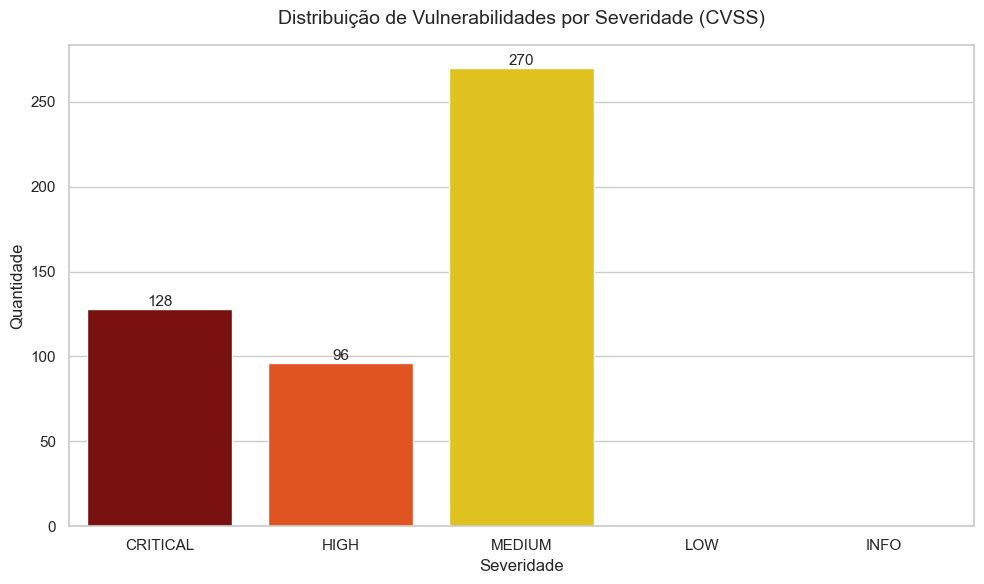

In [16]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_dataset, x='severity', order=['CRITICAL', 'HIGH', 'MEDIUM', 'LOW', 'INFO'], palette=cores_severidade)
plt.title('Distribuição de Vulnerabilidades por Severidade (CVSS)', fontsize=14, pad=15)
plt.xlabel('Severidade', fontsize=12)
plt.ylabel('Quantidade', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

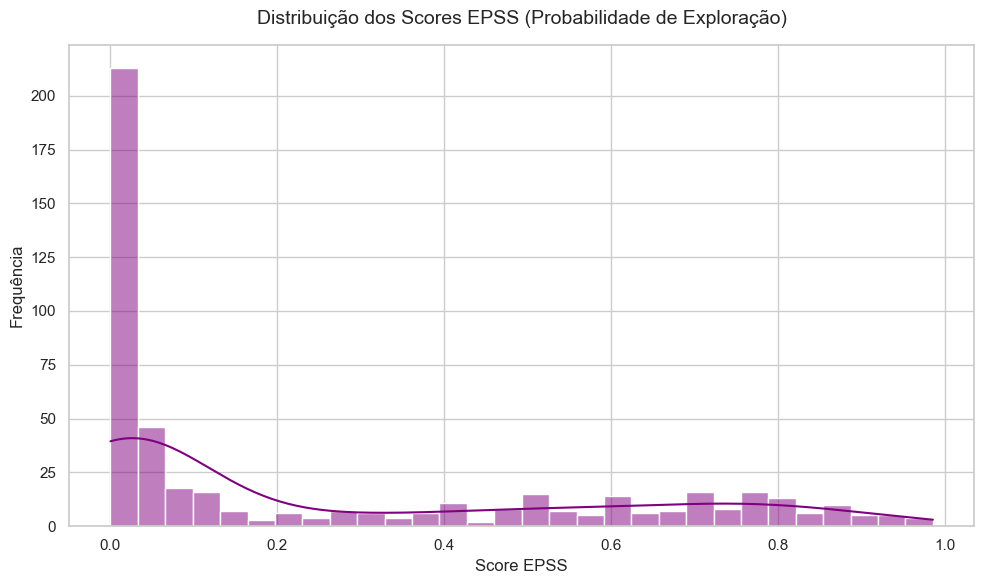

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_dataset, x='epss', bins=30, kde=True, color='purple')
plt.title('Distribuição dos Scores EPSS (Probabilidade de Exploração)', fontsize=14, pad=15)
plt.xlabel('Score EPSS', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.tight_layout()
plt.show()

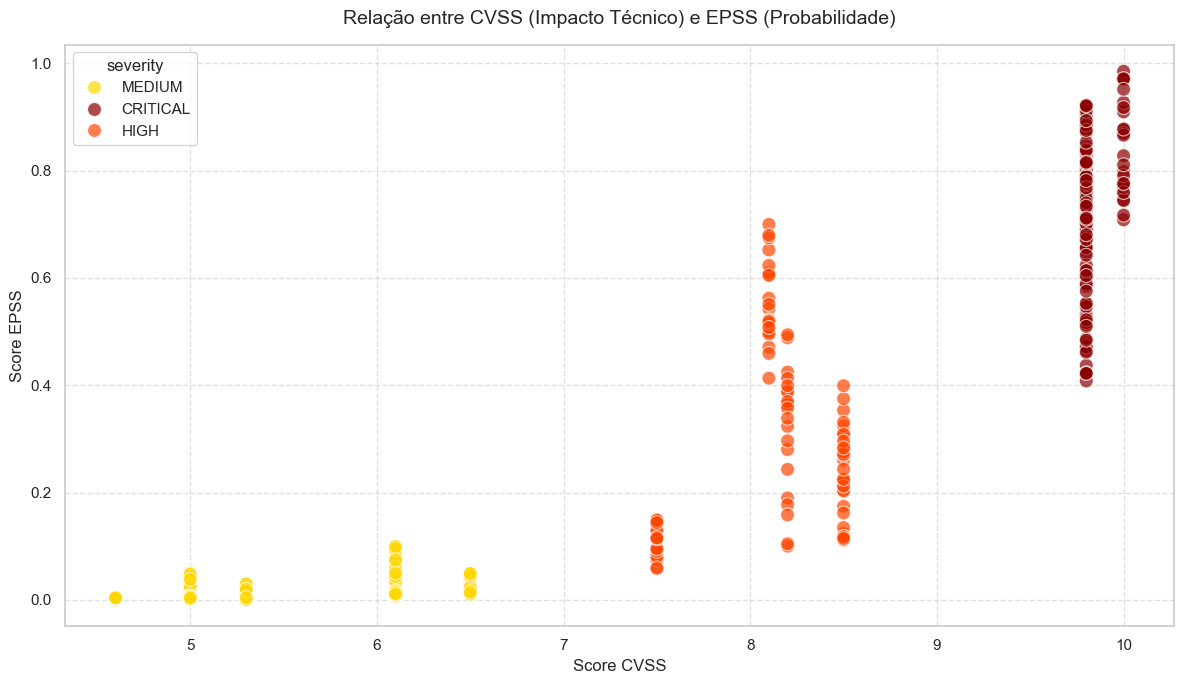

In [18]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_dataset, x='cvss', y='epss', hue='severity', palette=cores_severidade, s=100, alpha=0.7)
plt.title('Relação entre CVSS (Impacto Técnico) e EPSS (Probabilidade)', fontsize=14, pad=15)
plt.xlabel('Score CVSS', fontsize=12)
plt.ylabel('Score EPSS', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

C:\Users\john.araujo\AppData\Local\Temp\ipykernel_6672\2084195716.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_tcu, x='nivel de criticidade', order=['Alta', 'Média', 'Baixa'], palette=cores_tcu)


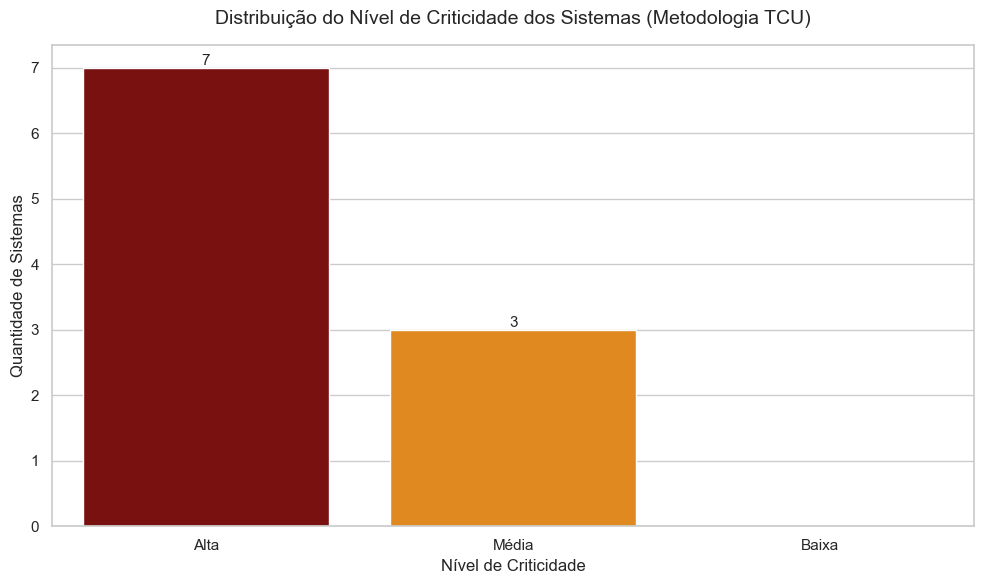

In [19]:
plt.figure(figsize=(10, 6))
df_tcu = pd.DataFrame(relatorio_linhas)
ax = sns.countplot(data=df_tcu, x='nivel de criticidade', order=['Alta', 'Média', 'Baixa'], palette=cores_tcu)
plt.title('Distribuição do Nível de Criticidade dos Sistemas (Metodologia TCU)', fontsize=14, pad=15)
plt.xlabel('Nível de Criticidade', fontsize=12)
plt.ylabel('Quantidade de Sistemas', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

C:\Users\john.araujo\AppData\Local\Temp\ipykernel_6672\3911533335.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_dataset, x='severity', y='ncs', order=['CRITICAL', 'HIGH', 'MEDIUM', 'LOW', 'INFO'], palette=cores_severidade)


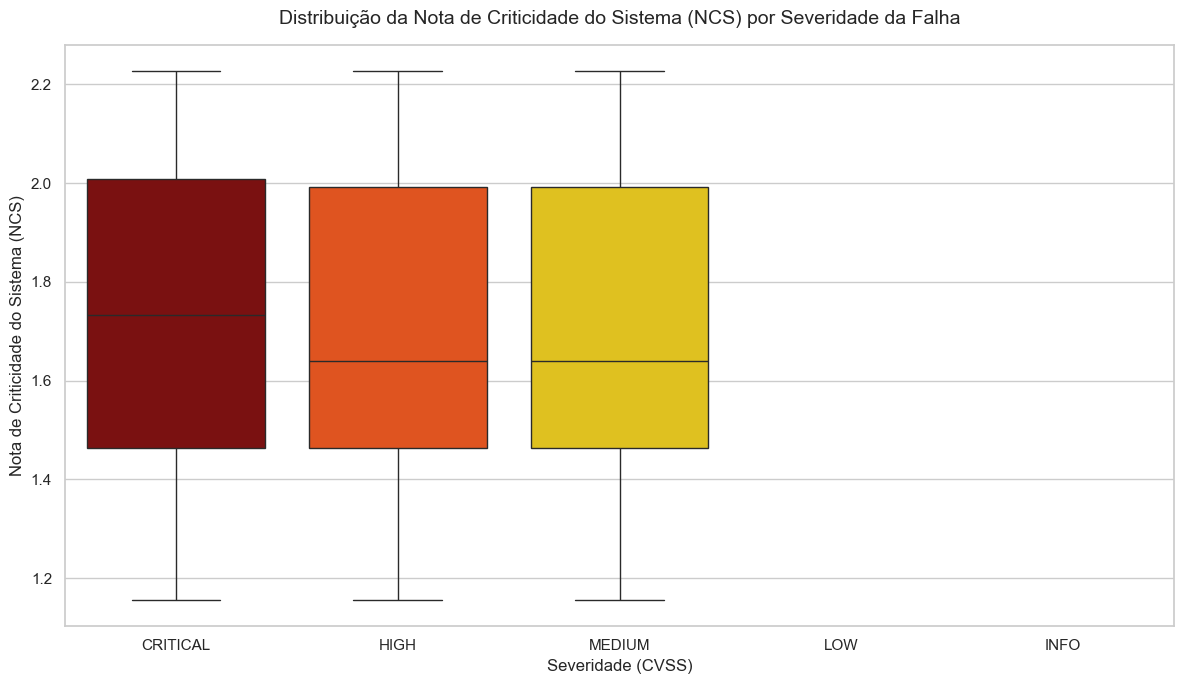

In [20]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=df_dataset, x='severity', y='ncs', order=['CRITICAL', 'HIGH', 'MEDIUM', 'LOW', 'INFO'], palette=cores_severidade)
plt.title('Distribuição da Nota de Criticidade do Sistema (NCS) por Severidade da Falha', fontsize=14, pad=15)
plt.xlabel('Severidade (CVSS)', fontsize=12)
plt.ylabel('Nota de Criticidade do Sistema (NCS)', fontsize=12)
plt.tight_layout()
plt.show()